<a href="https://colab.research.google.com/github/EmreCandan0/AskTheEarth/blob/dev/nb/Gemma3_(4B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [2]:
!pip -q install -U wandb
import wandb
wandb.login()

wandb: Currently logged in as: emrecandan4125 (emrecandan) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Unsloth

`FastModel` supports loading nearly any model now! This includes Vision and Text models!

In [3]:
from unsloth import FastModel
import torch

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-3-4b-it",
    max_seq_length = 2048, # Dataset tokenlar kontrol edilmeli
    load_in_4bit = True,
    full_finetuning = False,

)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.12.9: Fast Gemma3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.
Unsloth: Gemma3 does not support SDPA - switching to fast eager.


We now add LoRA adapters so we only need to update a small amount of parameters!

In [4]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,  # False denenecek

    r = 8,
    lora_alpha = 8,
    lora_dropout = 0.05,
    bias = "none",
    random_state = 3407,
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Unsloth: Making `model.base_model.model.model.language_model` require gradients


<a name="Data"></a>
### Data Prep
We now use the `Gemma-3` format for conversation style finetunes. We use [Maxime Labonne's FineTome-100k](https://huggingface.co/datasets/mlabonne/FineTome-100k) dataset in ShareGPT style. Gemma-3 renders multi turn conversations like below:

```
<bos><start_of_turn>user
Hello!<end_of_turn>
<start_of_turn>model
Hey there!<end_of_turn>
```

We use our `get_chat_template` function to get the correct chat template. We support `zephyr, chatml, mistral, llama, alpaca, vicuna, vicuna_old, phi3, llama3, phi4, qwen2.5, gemma3` and more.

In [5]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma-3",
)

In [6]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="./dataset.jsonl",
    split="train"
)

eval_dataset = load_dataset(
    "json",
    data_files="./eval.jsonl",
    split="train"
)

We now use `standardize_data_formats` to try converting datasets to the correct format for finetuning purposes!

In [7]:
from unsloth.chat_templates import standardize_data_formats
dataset = standardize_data_formats(dataset)
eval_dataset = standardize_data_formats(eval_dataset)

Let's see how row 100 looks like!

In [8]:
dataset[29]

{'id': 'ex30',
 'conversations': [{'role': 'system',
   'content': 'Sen AskTheEarth uygulamasında arazi analizi yapan bir AI asistanısın. NDVI aktifse NDVI yorumla.\n\nReferans:\n- NDVI: <0.2 çıplak, 0.2-0.4 seyrek, 0.4-0.6 orta, >0.6 yoğun\n\n[BAĞLAM]\n=== AskTheEarth Arazi Verisi ===\nAktif indeks: NDVI\n\n📊 NDVI İstatistikleri:\n  • Minimum: 0.1200\n  • Maksimum: 0.5900\n  • Ortalama: 0.3520\n  • Medyan: 0.3610\n  • Standart Sapma: 0.0910\n\n🗺️ Arazi Sınıflandırması:\n  • Seyrek Bitki: 58.0% ████████████\n  • Orta Yoğunluk: 34.0% ███████\n  • Çıplak/Toprak: 8.0% ██\n\n📍 Koordinatlar: 40.9600°N - 41.0200°N, 30.5800°E - 30.6600°E\nEk bilgi: Landcover=İğne yapraklı orman (evergreen), Mevsim=Kış'},
  {'role': 'user',
   'content': 'Kış olmasına rağmen burada orman var mı? Yeşillik sürüyor mu?'},
  {'role': 'assistant',
   'content': 'Aktif indeks NDVI ve ortalama **0.3520**: bu, seçili alanda **seyrek–orta düzey** yeşil aktivite olduğunu gösterir.\n\n- Sınıflandırmada Seyrek %58, Orta %

We now have to apply the chat template for `Gemma-3` onto the conversations, and save it to `text`. We remove the `<bos>` token using removeprefix(`'<bos>'`) since we're finetuning. The Processor will add this token before training and the model expects only one.

In [9]:
def formatting_prompts_func(examples):
   convos = examples["conversations"]
   texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False).removeprefix('<bos>') for convo in convos]
   return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)
eval_dataset = eval_dataset.map(formatting_prompts_func, batched = True)

Let's see how the chat template did! Notice there is no `<bos>` token as the processor tokenizer will be adding one.

In [10]:
eval_dataset[6]["text"]

"<start_of_turn>user\nSen AskTheEarth uygulamasında arazi analizi yapan bir AI asistanısın. Aktif indeks EVI ise EVI yorumla.\n\nReferans:\n- EVI: Bitki aktivitesi. NDVI'ya benzer, yoğun bitkide daha kararlı olabilir.\n\n[BAĞLAM]\n=== AskTheEarth Arazi Verisi ===\nAktif indeks: EVI\n\n📊 EVI İstatistikleri:\n  • Minimum: 0.0800\n  • Maksimum: 0.5200\n  • Ortalama: 0.2860\n  • Medyan: 0.2790\n  • Standart Sapma: 0.0940\n\n🗺️ Arazi Sınıflandırması:\n  • Orta Aktivite: 58.0% ████████████\n  • Düşük Aktivite: 34.0% ███████\n  • Yüksek Aktivite: 8.0% ██\n\n📍 Koordinatlar: 37.6900°N - 37.7600°N, 29.9800°E - 30.0700°E\nEk bilgi: Mevsim=Sonbahar\n\nBitki aktivitesi sonbaharda düşmüş mü? Bu normal mi?<end_of_turn>\n<start_of_turn>model\nAktif indeks EVI ve ortalama **0.2860**: bu, seçili alanda **düşük-orta** seviyede bitki aktivitesi olduğunu gösterir. Sınıflandırmada Orta %58 olsa da Düşük %34 önemli bir pay; sonbaharda birçok bitkide yeşil aktivitenin azalması normaldir. Eğer yaz aylarında ay

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`.

In [11]:
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    eval_dataset = eval_dataset,
    args = SFTConfig(
        fp16_full_eval = True,
        per_device_eval_batch_size = 2,
        eval_accumulation_steps = 4,
        eval_strategy="steps",
        eval_steps=2,
        save_strategy = "steps",
        save_steps = 2,
        dataset_text_field = "text",
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_ratio = 0.1,
        max_steps = 30,
        learning_rate = 1e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        load_best_model_at_end = True,
        metric_for_best_model = "eval_loss",
        greater_is_better = False,
        report_to = "wandb",
        logging_first_step=True,
    ),
)

Unsloth: Switching to float32 training since model cannot work with float16


We also use Unsloth's `train_on_completions` method to only train on the assistant outputs and ignore the loss on the user's inputs. This helps increase accuracy of finetunes!

In [12]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<start_of_turn>user\n",
    response_part = "<start_of_turn>model\n",
)

Let's verify masking the instruction part is done! Let's print the 100th row again.  Notice how the sample only has a single `<bos>` as expected!

In [13]:
tokenizer.decode(trainer.eval_dataset[6]["input_ids"])

"<bos><start_of_turn>user\nSen AskTheEarth uygulamasında arazi analizi yapan bir AI asistanısın. Aktif indeks EVI ise EVI yorumla.\n\nReferans:\n- EVI: Bitki aktivitesi. NDVI'ya benzer, yoğun bitkide daha kararlı olabilir.\n\n[BAĞLAM]\n=== AskTheEarth Arazi Verisi ===\nAktif indeks: EVI\n\n📊 EVI İstatistikleri:\n  • Minimum: 0.0800\n  • Maksimum: 0.5200\n  • Ortalama: 0.2860\n  • Medyan: 0.2790\n  • Standart Sapma: 0.0940\n\n🗺️ Arazi Sınıflandırması:\n  • Orta Aktivite: 58.0% ████████████\n  • Düşük Aktivite: 34.0% ███████\n  • Yüksek Aktivite: 8.0% ██\n\n📍 Koordinatlar: 37.6900°N - 37.7600°N, 29.9800°E - 30.0700°E\nEk bilgi: Mevsim=Sonbahar\n\nBitki aktivitesi sonbaharda düşmüş mü? Bu normal mi?<end_of_turn>\n<start_of_turn>model\nAktif indeks EVI ve ortalama **0.2860**: bu, seçili alanda **düşük-orta** seviyede bitki aktivitesi olduğunu gösterir. Sınıflandırmada Orta %58 olsa da Düşük %34 önemli bir pay; sonbaharda birçok bitkide yeşil aktivitenin azalması normaldir. Eğer yaz ayların

Now let's print the masked out example - you should see only the answer is present:

In [14]:
tokenizer.decode([tokenizer.pad_token_id if x == -100 else x for x in trainer.train_dataset[29]["labels"]]).replace(tokenizer.pad_token, " ")
tokenizer.decode([tokenizer.pad_token_id if x == -100 else x for x in trainer.eval_dataset[6]["labels"]]).replace(tokenizer.pad_token, " ")

'                                                                                                                                                                                                                                                                                                               Aktif indeks EVI ve ortalama **0.2860**: bu, seçili alanda **düşük-orta** seviyede bitki aktivitesi olduğunu gösterir. Sınıflandırmada Orta %58 olsa da Düşük %34 önemli bir pay; sonbaharda birçok bitkide yeşil aktivitenin azalması normaldir. Eğer yaz aylarında aynı alanda EVI daha yüksekse (ör. 0.4–0.6 bandı), bu düşüş mevsimsel olgunlaşma/kuruma ile uyumlu olur. Tek tarihle kesin karar vermek yerine zaman serisi kıyaslaması önerilir.<end_of_turn>\n'

In [15]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
5.59 GB of memory reserved.


Let's train the model! To resume a training run, set `trainer.train(resume_from_checkpoint = True)`

In [16]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 30 | Num Epochs = 8 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 14,901,248 of 4,314,980,720 (0.35% trained)


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
2,3.153900,2.721456
4,3.169300,2.454910
6,2.616200,2.299639
8,2.488800,2.187965
10,2.369200,2.089127
12,2.397100,2.008520
14,2.125700,1.946432
16,2.194700,1.897141
18,2.111000,1.856590
20,2.020500,1.821372


Unsloth: Not an error, but Gemma3ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


eval/loss,█▆▅▄▄▃▃▂▂▂▁▁▁▁▁
eval/runtime,█▄▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/samples_per_second,▁▂██▇▇▇▇▇▇▇▇▇▇▇
eval/steps_per_second,▁▂██▇▇▇▇▇▇▇▇▇▇▇
train/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
train/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/grad_norm,▇▅██▃▂▂▂▁▂▂▂▁▁▁▂▁▁▁▁▂▂▁▂▁▂▁▂▁▁
train/learning_rate,▁▃▆██▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁
train/loss,████▇▅▅▅▅▄▄▄▄▃▃▄▃▃▂▃▃▂▂▂▂▂▂▂▁▂
eval/loss,1.72529
eval/runtime,2.6328


In [25]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

434.8871 seconds used for training.
7.25 minutes used for training.
Peak reserved memory = 6.697 GB.
Peak reserved memory for training = 1.107 GB.
Peak reserved memory % of max memory = 45.431 %.
Peak reserved memory for training % of max memory = 7.51 %.


<a name="Inference"></a>
### Inference
Let's run the model via Unsloth native inference! According to the `Gemma-3` team, the recommended settings for inference are `temperature = 1.0, top_p = 0.95, top_k = 64`

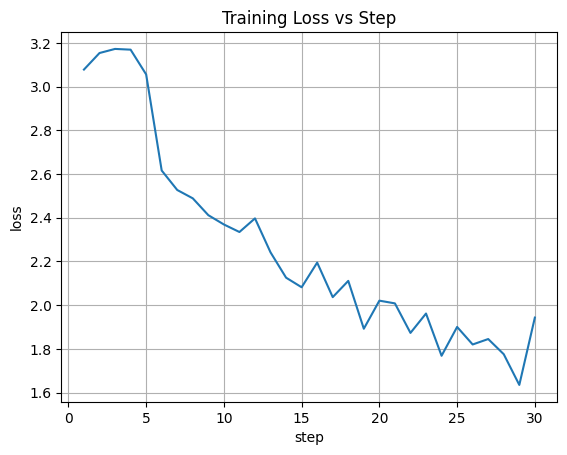

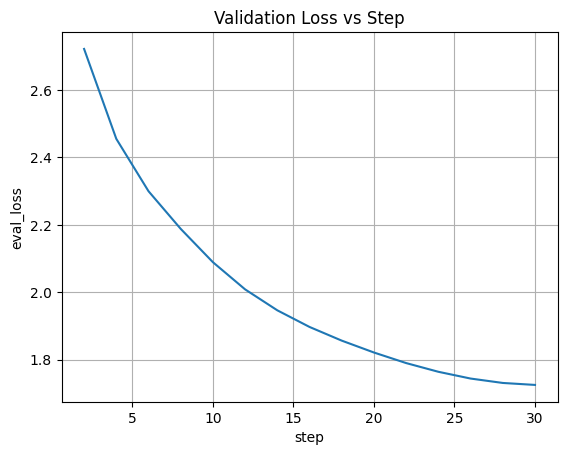

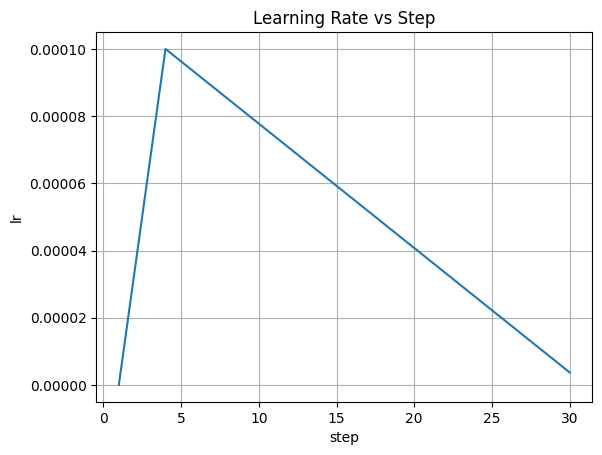

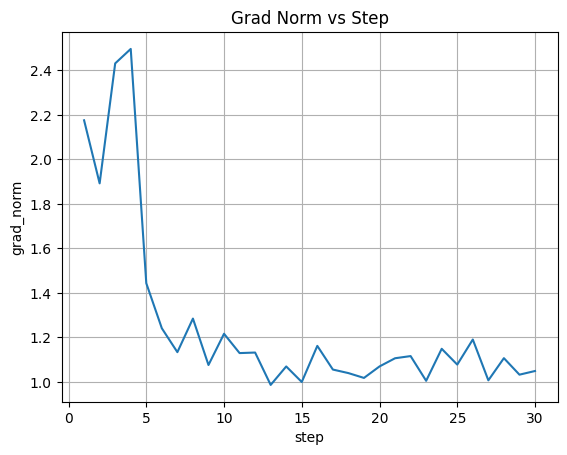

In [18]:
import matplotlib.pyplot as plt

def extract_series(log_history, key):
    xs, ys = [], []
    for row in log_history:
        if key in row:
            # HuggingFace Trainer loglarında step bazen "step" bazen "global_step" olur
            step = row.get("step", row.get("global_step", None))
            if step is None:
                continue
            xs.append(step)
            ys.append(row[key])
    return xs, ys

def plot_series(x, y, title, xlabel="step", ylabel=None):
    if not x:
        print(f"[WARN] '{title}' için veri yok.")
        return
    plt.figure()
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

# Eğitim bittikten sonra:
log_history = trainer.state.log_history

# 1) Train loss (loglarda genelde key: "loss")
x_train, y_train = extract_series(log_history, "loss")
plot_series(x_train, y_train, "Training Loss vs Step", ylabel="loss")

# 2) Eval loss (key: "eval_loss")
x_eval, y_eval = extract_series(log_history, "eval_loss")
plot_series(x_eval, y_eval, "Validation Loss vs Step", ylabel="eval_loss")

# 3) Learning rate
x_lr, y_lr = extract_series(log_history, "learning_rate")
plot_series(x_lr, y_lr, "Learning Rate vs Step", ylabel="lr")

# 4) Grad norm (loglanıyorsa)
x_gn, y_gn = extract_series(log_history, "grad_norm")
plot_series(x_gn, y_gn, "Grad Norm vs Step", ylabel="grad_norm")


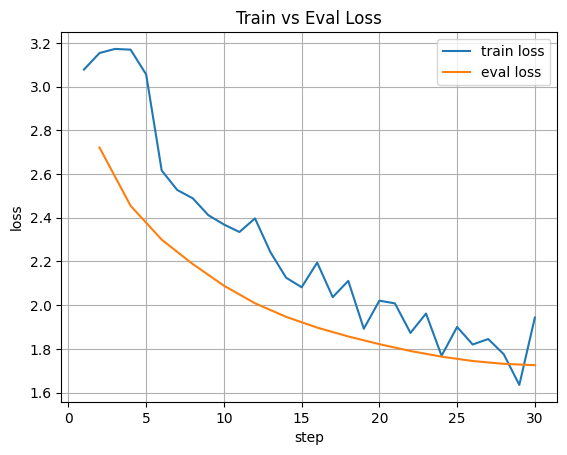

In [19]:
plt.figure()
if x_train:
    plt.plot(x_train, y_train, label="train loss")
if x_eval:
    plt.plot(x_eval, y_eval, label="eval loss")
plt.title("Train vs Eval Loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.grid(True)
plt.legend()
plt.show()


In [20]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma-3",
)
messages = [{
    "role": "user",
    "content": [{
        "type" : "text",
        "text" : "Continue the sequence: 1, 1, 2, 3, 5, 8,",
    }]
}]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True, # Must add for generation
    tokenize = True,
    return_tensors = "pt",
    return_dict = True,
)
outputs = model.generate(
    **inputs.to("cuda"),
    max_new_tokens = 64, # Increase for longer outputs!
    # Recommended Gemma-3 settings!
    temperature = 1.0, top_p = 0.95, top_k = 64,
)
tokenizer.batch_decode(outputs)

['<bos><start_of_turn>user\nContinue the sequence: 1, 1, 2, 3, 5, 8,<end_of_turn>\n<start_of_turn>model\n13, 21, 34, 55,...\n\nThis is the Fibonacci sequence, where each number is the sum of the two preceding ones.\n*   1 + 1 = 2\n*   1 + 2 = 3\n*   2 + 3 = 5']

 You can also use a `TextStreamer` for continuous inference - so you can see the generation token by token, instead of waiting the whole time!

In [21]:
messages = [{
    "role": "user",
    "content": [{"type" : "text", "text" : "NDVI hakkında ne söyleyebilirsin?",}]
}]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True, # Must add for generation
    tokenize = True,
    return_tensors = "pt",
    return_dict = True,
)

from transformers import TextStreamer
_ = model.generate(
    **inputs.to("cuda"),
    max_new_tokens = 64, # Increase for longer outputs!
    # Recommended Gemma-3 settings!
    temperature = 1.0, top_p = 0.95, top_k = 64,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

Okay, let's break down why the sky is blue – it's a beautiful example of a phenomenon called **Rayleigh scattering**. Here’s a breakdown of the explanation:

**1. Sunlight & Colors:**

* Sunlight isn't just white light! It's actually made up of *all


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Huggingface's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [22]:
model.save_pretrained("gemma-3")  # Local saving
tokenizer.save_pretrained("gemma-3")


['gemma-3/processor_config.json']

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [37]:
import torch
from transformers import TextStreamer

model.eval()

messages = [
    {
        "role": "system",
        "content": [
            {
                "type": "text",
                "text": """Sen AskTheEarth uygulamasında arazi analizi yapan bir AI asistanısın. Aktif indeks EVI ise EVI yorumla.

Referans:
- EVI: Bitki aktivitesi. NDVI'ya benzer, yoğun bitkide daha kararlı olabilir.

[BAĞLAM]
=== AskTheEarth Arazi Verisi ===
Aktif indeks: EVI

📊 EVI İstatistikleri:
  • Minimum: 0.0800
  • Maksimum: 0.5200
  • Ortalama: 0.2860
  • Medyan: 0.2790
  • Standart Sapma: 0.0940

🗺️ Arazi Sınıflandırması:
  • Orta Aktivite: 58.0% ████████████
  • Düşük Aktivite: 34.0% ███████
  • Yüksek Aktivite: 8.0% ██

📍 Koordinatlar: 37.6900°N - 37.7600°N, 29.9800°E - 30.0700°E
Ek bilgi: Mevsim=Sonbahar"""
            }
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Bitki aktivitesi sonbaharda düşmüş mü? Bu normal mi?"}
        ],
    },
]

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
)

# inputs dict -> cuda
inputs = {k: v.to("cuda") for k, v in inputs.items()}

streamer = TextStreamer(tokenizer, skip_prompt=True)

with torch.no_grad():
    _ = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.7,
        top_p=0.9,
        top_k=50,
        streamer=streamer,
    )


Aktif indeks EVI ise EVI yorum:

Aktif indeks EVI ise EVI yorum:

Aktif indeks EVI ise EVI yorum:

Aktif indeks EVI ise EVI yorum:

Aktif indeks EVI ise EVI yorum:

Aktif indeks EVI ise EVI yorum:

Aktif indeks EVI ise EVI yorum:

Aktif indeks EVI ise EVI yorum:

Aktif indeks EVI ise EVI yorum:

Aktif indeks EVI ise EVI yorum:

Aktif indeks EVI ise EVI yorum:

Aktif indeks EVI ise EVI yorum:

Aktif 

KeyboardInterrupt: 

### GGUF / llama.cpp Conversion
To save to `GGUF` / `llama.cpp`, we support it natively now for all models! For now, you can convert easily to `Q8_0, F16 or BF16` precision. `Q4_K_M` for 4bit will come later!

In [29]:
if True: # Change to True to save to GGUF
    model.save_pretrained_gguf(
        "gemma-3-finetune",
        tokenizer,
        quantization_method = "Q8_0", # For now only Q8_0, BF16, F16 supported
    )

Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### Your chat template has a BOS token. We shall remove it temporarily.


Unsloth: Merging model weights to 16-bit format...


config.json: 0.00B [00:00, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [06:06<00:00, 183.33s/it]


Unsloth: Merge process complete. Saved to `/content/gemma-3-finetune`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q8_0'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: All required system packages already installed!
Unsloth: Install llama.cpp and building - please wait 1 to 3 minutes
Unsloth: Cloning llama.cpp repository
Unsloth: Install GGUF and other packages
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['gemma-3-4b-it.F16.gguf', 'gemma-3-4b

Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### We removed it in GGUF's chat template for you.


Unsloth: All GGUF conversions completed successfully!
Generated files: ['gemma-3-4b-it.Q8_0.gguf', 'gemma-3-4b-it.F16-mmproj.gguf']


Unsloth: example usage for Multimodal LLMs: llama-mtmd-cli -m gemma-3-4b-it.Q8_0.gguf --mmproj gemma-3-4b-it.F16-mmproj.gguf
Unsloth: load image inside llama.cpp runner: /image test_image.jpg
Unsloth: Prompt model to describe the image
Unsloth: Saved Ollama Modelfile to gemma-3-finetune/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f ./Modelfile - inside save directory.


In [34]:

!mkdir -p "/content/drive/MyDrive/asktheearth_models"
!cp -f "/content/gemma-3-4b-it.Q8_0.gguf" "/content/drive/MyDrive/asktheearth_models/"
